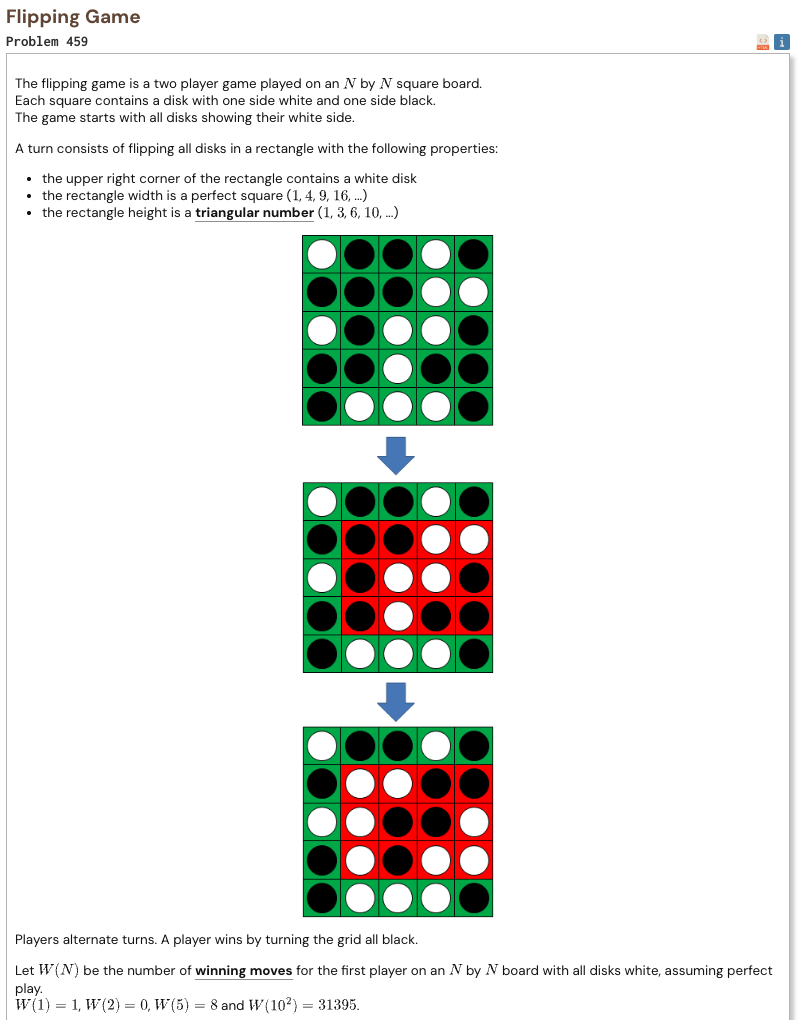

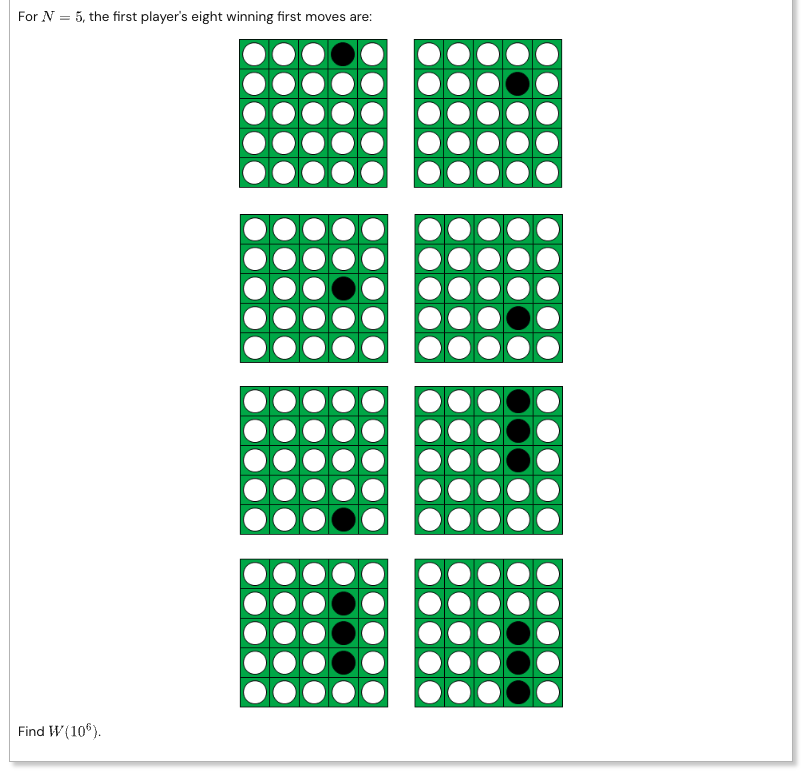

## Initial approach

-   split the board game into one game for triangular heights and one game for square widths
-   use Grundy numbers to describe whether each one dimensional game position is winning or losing
-   keep prefix xor values so the result of every possible move can be calculated quickly
-   count how often each move Grundy value occurs instead of storing every rectangle separately
-   combine the vertical and horizontal move values using nimber multiplication
-   a first move is winning when its combined nimber matches the nimber of the full board
-   use numba to compile the large nested loops because pure Python would be much too slow for one million
-   count all matching height and width combinations to obtain the final number of winning moves

In [1]:
%%time

import numpy as np
from numba import njit
from functools import lru_cache

N = 1_000_000
MAX_NIMBER = 1024

@njit
def compute_axis(n, lengths):
    prefix = np.zeros(n + 1, dtype=np.int32)
    histogram = np.zeros(MAX_NIMBER, dtype=np.int64)
    seen = np.full(MAX_NIMBER, -1, dtype=np.int32)
    counts = np.zeros(MAX_NIMBER, dtype=np.int32)
    touched = np.empty(MAX_NIMBER, dtype=np.int32)

    active = 0

    for x in range(1, n + 1):
        while active < len(lengths) and lengths[active] <= x:
            active += 1

        previous = prefix[x - 1]
        touched_count = 0

        for i in range(active):
            value = previous ^ prefix[x - lengths[i]]

            if counts[value] == 0:
                touched[touched_count] = value
                touched_count += 1

            counts[value] += 1
            seen[value] = x

        mex = 0

        while seen[mex] == x:
            mex += 1

        prefix[x] = previous ^ mex

        for i in range(touched_count):
            value = touched[i]
            histogram[mex ^ value] += counts[value]
            counts[value] = 0

    return prefix[n], histogram

@lru_cache(None)
def nim_multiply(a, b):
    result = 0
    i = 0

    while a >> i:
        if (a >> i) & 1:
            j = 0

            while b >> j:
                if (b >> j) & 1:
                    value = 1 << (i ^ j)
                    common = i & j
                    bit = 0

                    while common >> bit:
                        if (common >> bit) & 1:
                            factor = 3 * (1 << ((1 << bit) - 1))
                            value = nim_multiply(value, factor)

                        bit += 1

                    result ^= value

                j += 1

        i += 1

    return result

squares = np.array(
    [k * k for k in range(1, int(N**0.5) + 1)],
    dtype=np.int32
)

triangles = []

k = 1

while k * (k + 1) // 2 <= N:
    triangles.append(k * (k + 1) // 2)
    k += 1

triangles = np.array(triangles, dtype=np.int32)

square_total, square_histogram = compute_axis(N, squares)
triangle_total, triangle_histogram = compute_axis(N, triangles)

target = nim_multiply(square_total, triangle_total)

result = 0

square_values = np.nonzero(square_histogram)[0]
triangle_values = np.nonzero(triangle_histogram)[0]

for a in square_values:
    for b in triangle_values:
        if nim_multiply(int(a), int(b)) == target:
            result += (
                int(square_histogram[a])
                * int(triangle_histogram[b])
            )

print("Result:", result)

Result: 3996390106631
CPU times: user 8.86 s, sys: 184 ms, total: 9.05 s
Wall time: 12.3 s
